# Predicting Bottom Dissolved Oxygen from Surface Variables

In this module, we build a complete machine learning workflow using real environmental data.

We demonstrate how to predict bottom dissolved oxygen (DO) using surface water quality variables from the Chesapeake Bay Program (CBP) DataHub, including:

* Chlorophyll-a
* Salinity
* Nutrients (TN, TP)
* Water temperature (WTEMP)

The raw data used in this tutorial can be downloaded from:
https://datahub.chesapeakebay.net/WaterQuality

We use data from three mainstem stations across the Chesapeake Bay (1984–2024):

* Upper Bay: CB3.2
* Middle Bay: CB5.1
* Lower Bay: CB6.4


We will follow a complete workflow:

Raw Data → Clean Data → Train Model → Predict



## Learning Objectives

* Prepare raw water quality data for machine learning
* Build and evaluate predictive models (Random Forest and MLP)
* Understand how input variables influence model predictions
* Apply trained models to new datasets for DO prediction
* Compare model performance and interpret results


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!git clone https://github.com/CGC-UMCES/WORKSHOP-Intro-ML-Predict-DO.git /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO

####<font color="#FF69B4">PROMPT: "Please set the working directory to /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO"

In [ ]:
import os

working_directory = '/content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML'
os.chdir(working_directory)
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML


## Section 1: Data Cleaning and Preparation

### What You Will Do

* Load and explore raw data
* Handle missing values and duplicates
* Filter and organize variables
* Create a model-ready dataset

### Key Idea

Clean and consistent data is essential for building reliable models.


####<font color="#FF69B4">PROMPT: "Please display the image: map_of_mainstem_and_tributary_monitoring_stations.png"

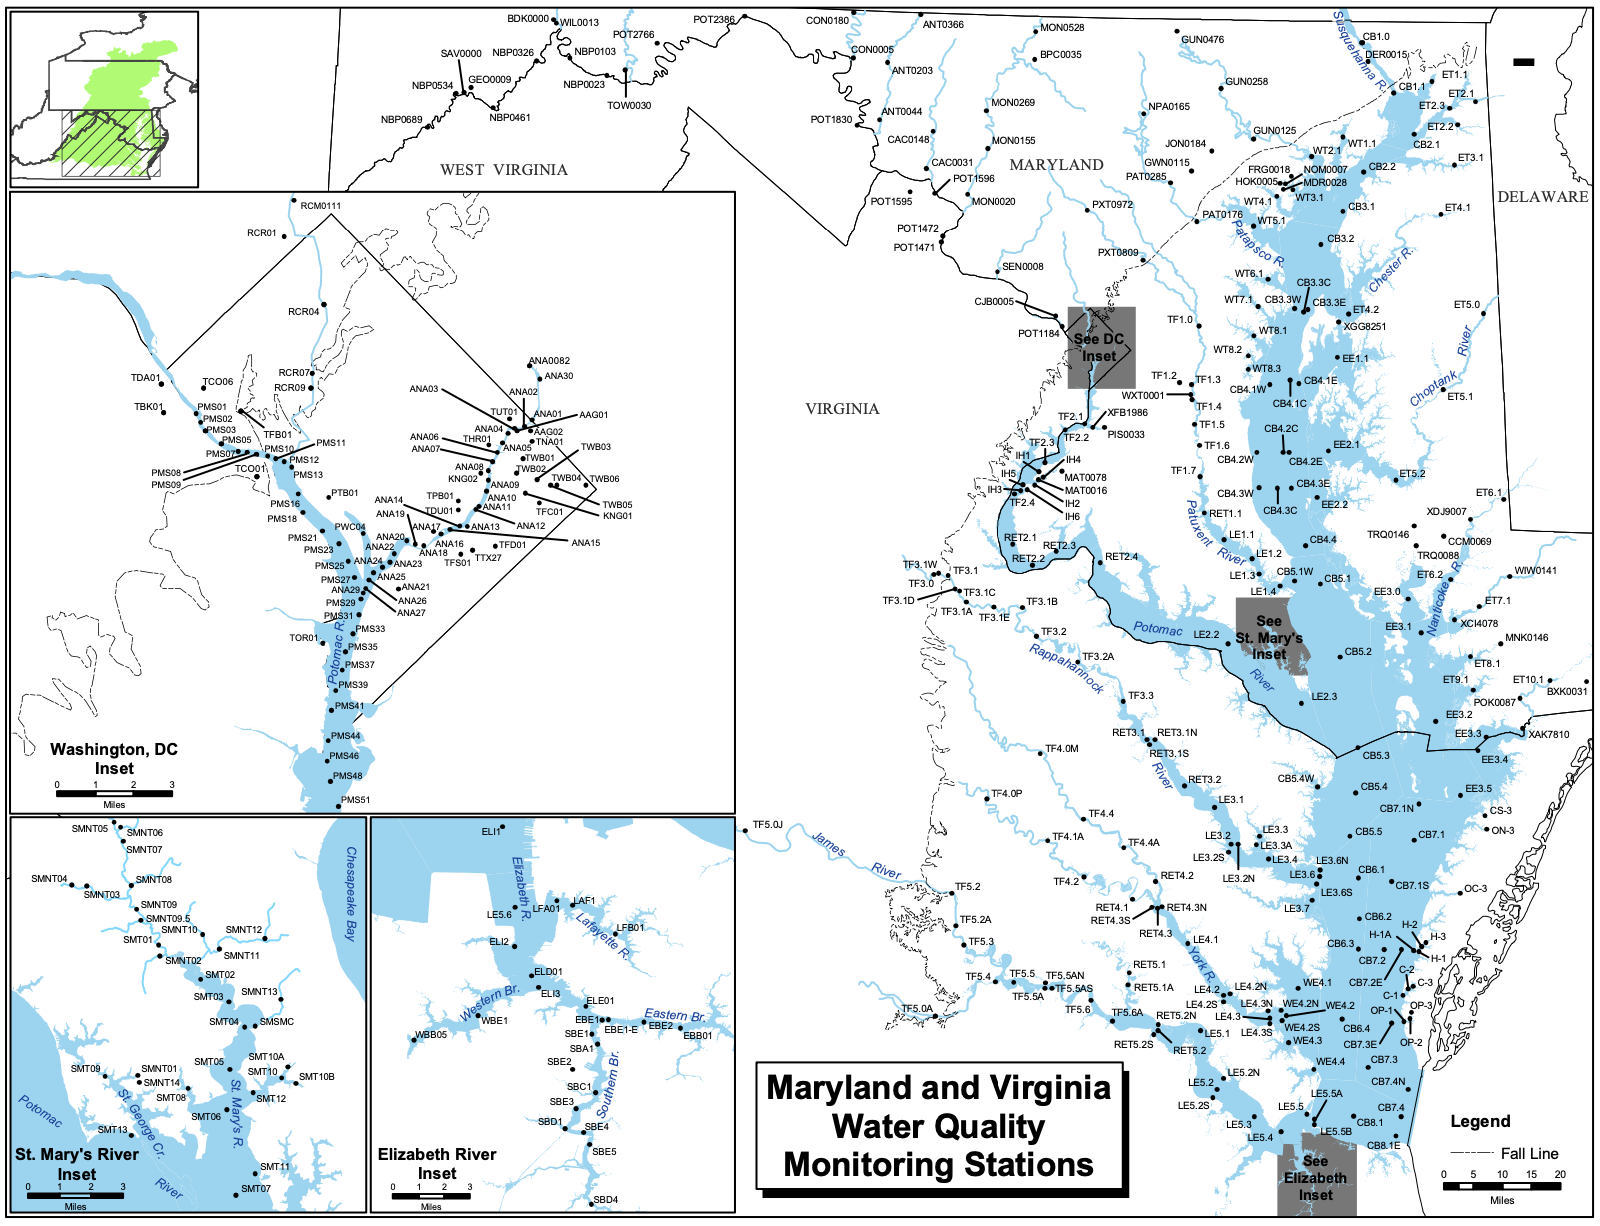

In [ ]:
from IPython.display import Image
Image('map_of_mainstem_and_tributary_monitoring_stations.png')

####<font color="#FF69B4">PROMPT: "Please read the file "CBP_RawData/Upper_StationCB3.2.csv" using pandas and store it in df."

In [ ]:
import pandas as pd
df = pd.read_csv('CBP_RawData/Upper_StationCB3.2.csv')
print("DataFrame df created successfully.")
df.head()

DataFrame df created successfully.


,MonitoringStation,EventId,SampleDate,Layer,Parameter,MeasureValue,Unit
0,CB3.2,126589,7/12/84,B,CHLA,4.0,UG/L
1,CB3.2,126589,7/12/84,S,CHLA,2.7,UG/L
2,CB3.2,126589,7/12/84,BP,CHLA,1.3,UG/L
3,CB3.2,126707,7/25/84,AP,CHLA,5.3,UG/L
4,CB3.2,126707,7/25/84,B,CHLA,5.3,UG/L


####<font color="#FF69B4">PROMPT: "Please display how many rows in the df."

In [ ]:
print(f"Total number of rows in df: {df.shape[0]}")

Total number of rows in df: 30561


####<font color="#FF69B4">PROMPT: "Please show, for each column in df: the value range, the number of unique values, and up to 10 example unique values"

In [ ]:
import pandas as pd

for col in df.columns:
    print(f"\n--- Column: {col} ---")

    # Number of unique values
    unique_count = df[col].nunique()
    print(f"Unique values count: {unique_count}")

    # Display up to 10 unique values
    unique_values_sample = df[col].unique()
    if unique_count > 10:
        print(f"Sample of unique values (first 10): {unique_values_sample[:10].tolist()}")
    else:
        print(f"All unique values: {unique_values_sample.tolist()}")

    # Value Range for numeric and datetime columns
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Value Range (Min, Max): ({df[col].min()}, {df[col].max()})")
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        print(f"Value Range (Min, Max): ({df[col].min().strftime('%Y-%m-%d')}, {df[col].max().strftime('%Y-%m-%d')})")
    else:
        print("Value Range: N/A (non-numeric/non-datetime type)")


--- Column: MonitoringStation ---
Unique values count: 1
All unique values: ['CB3.2']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: EventId ---
Unique values count: 667
Sample of unique values (first 10): [126589, 126707, 126820, 126931, 127400, 127162, 127033, 127292, 127456, 127807]
Value Range (Min, Max): (39, 691267)

--- Column: SampleDate ---
Unique values count: 667
Sample of unique values (first 10): ['7/12/84', '7/25/84', '8/7/84', '8/30/84', '10/24/84', '9/26/84', '9/12/84', '10/10/84', '11/7/84', '2/13/85']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: Layer ---
Unique values count: 5
All unique values: ['B ', 'S ', 'BP', 'AP', 'M ']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: Parameter ---
Unique values count: 6
All unique values: ['CHLA', 'DO', 'SALINITY', 'TN', 'TP', 'WTEMP']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: MeasureValue ---
Unique values count: 3569
Sample of unique values (first 10): [4.0, 2

####<font color="#FF69B4">PROMPT: "Please check for NaN values and display the rows that contain NaN in the df."

In [ ]:
print("Checking for missing values (NaN) in df:")
missing_values_rows = df[df.isnull().any(axis=1)]

if missing_values_rows.empty:
    print("No missing values found in df.")
else:
    print(f"Found {len(missing_values_rows)} rows with missing values in df:")
    print(missing_values_rows.to_string())

Checking for missing values (NaN) in df:
Found 30 rows with missing values in df:
      MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
217               CB3.2   131992    5/29/08    BP      CHLA           NaN  UG/L
346               CB3.2   416754    1/28/16    AP      CHLA           NaN  UG/L
873               CB3.2   487677   12/23/20    S       CHLA           NaN  UG/L
1507              CB3.2    68363    3/16/11    AP      CHLA           NaN  UG/L
1940              CB3.2    33551    1/12/05    AP      CHLA           NaN  UG/L
2172              CB3.2   105269    6/17/09    B       CHLA           NaN  UG/L
4562              CB3.2   444747    9/27/17    S         DO           NaN  MG/L
4563              CB3.2   444747    9/27/17    M         DO           NaN  MG/L
4564              CB3.2   444747    9/27/17    M         DO           NaN  MG/L
4573              CB3.2   444747    9/27/17    AP        DO           NaN  MG/L
4577              CB3.2   444747    9/

####<font color="#FF69B4">PROMPT: "Please remove all rows containing NaN values from df, save the result as df_clean_NaN, and display it."

In [ ]:
print(f"Original number of rows in df: {df.shape[0]}")
df_clean_NaN = df.dropna()
print(f"Number of rows in df_clean_NaN after removing NaNs: {df_clean_NaN.shape[0]}")
print("First 5 rows of df_clean_NaN:")
print(df_clean_NaN.head().to_string())

Original number of rows in df: 30561
Number of rows in df_clean_NaN after removing NaNs: 30531
First 5 rows of df_clean_NaN:
  MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
0             CB3.2   126589    7/12/84    B       CHLA           4.0  UG/L
1             CB3.2   126589    7/12/84    S       CHLA           2.7  UG/L
2             CB3.2   126589    7/12/84    BP      CHLA           1.3  UG/L
3             CB3.2   126707    7/25/84    AP      CHLA           5.3  UG/L
4             CB3.2   126707    7/25/84    B       CHLA           5.3  UG/L


####<font color="#FF69B4">PROMPT: "Please convert the "SampleDate" column in df_clean_NaN to datetime format, and display it."

In [ ]:
import pandas as pd
df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])
print("'SampleDate' column in df_clean_NaN converted to datetime format.")
print(df_clean_NaN['SampleDate'].head())

'SampleDate' column in df_clean_NaN converted to datetime format.
0   1984-07-12
1   1984-07-12
2   1984-07-12
3   1984-07-25
4   1984-07-25
Name: SampleDate, dtype: datetime64[ns]


/tmp/ipykernel_24074/2613077186.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])
/tmp/ipykernel_24074/2613077186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])


####<font color="#FF69B4">PROMPT: "Please randomly select one date and display the rows from that date in df_clean_NaN."

In [ ]:
import numpy as np
import pandas as pd

# Ensure 'SampleDate' is datetime type
if not pd.api.types.is_datetime64_any_dtype(df_clean_NaN['SampleDate']):
    df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])

# Randomly select one unique date from the 'SampleDate' column
random_date_np = np.random.choice(df_clean_NaN['SampleDate'].unique())

# Convert the numpy.datetime64 to pandas Timestamp for easier comparison
random_date_pd = pd.Timestamp(random_date_np)

print(f"Randomly chosen date: {random_date_pd.strftime('%Y-%m-%d')}")

# Filter the DataFrame to display rows for the chosen date
df_random_date = df_clean_NaN[df_clean_NaN['SampleDate'] == random_date_pd]
print(df_random_date.to_string())

Randomly chosen date: 1986-05-28
      MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue   Unit
1242              CB3.2   115375 1986-05-28    S       CHLA       19.6000   UG/L
1243              CB3.2   115375 1986-05-28    BP      CHLA       16.3000   UG/L
1244              CB3.2   115375 1986-05-28    AP      CHLA       17.2000   UG/L
1245              CB3.2   115375 1986-05-28    B       CHLA        9.6000   UG/L
6751              CB3.2   115375 1986-05-28    B         DO        0.5000   MG/L
6752              CB3.2   115375 1986-05-28    M         DO        2.2000   MG/L
6753              CB3.2   115375 1986-05-28    M         DO        1.4000   MG/L
6754              CB3.2   115375 1986-05-28    M         DO        2.8000   MG/L
6755              CB3.2   115375 1986-05-28    M         DO        0.8000   MG/L
6756              CB3.2   115375 1986-05-28    M         DO        7.1000   MG/L
6757              CB3.2   115375 1986-05-28    BP        DO        3.7000   

####<font color="#FF69B4">PROMPT: "Please check if there are  duplicate measurements in df_clean_NaN"


In [ ]:
print("Checking for duplicate measurements (same MonitoringStation, SampleDate, Layer, and Parameter) in `df_clean_NaN`:")
duplicate_check_cols = ['MonitoringStation', 'SampleDate', 'Layer', 'Parameter']
duplicates_in_df_clean_NaN = df_clean_NaN[df_clean_NaN.duplicated(subset=duplicate_check_cols, keep=False)]

if not duplicates_in_df_clean_NaN.empty:
    print(f"Found {len(duplicates_in_df_clean_NaN)} rows in `df_clean_NaN` that have duplicate measurements for the same station, date, layer, and parameter combination.")
    print("Here are the first 10 entries of these duplicates:")
    print(duplicates_in_df_clean_NaN.sort_values(by=duplicate_check_cols).head(10).to_string())
else:
    print("No duplicate measurements found in `df_clean_NaN` for the same station, date, layer, and parameter combination.")

Checking for duplicate measurements (same MonitoringStation, SampleDate, Layer, and Parameter) in `df_clean_NaN`:
Found 15348 rows in `df_clean_NaN` that have duplicate measurements for the same station, date, layer, and parameter combination.
Here are the first 10 entries of these duplicates:
     MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
3061             CB3.2   126589 1984-07-12    M         DO           4.3  MG/L
3062             CB3.2   126589 1984-07-12    M         DO           3.6  MG/L
3064             CB3.2   126589 1984-07-12    M         DO           5.0  MG/L
3065             CB3.2   126589 1984-07-12    M         DO           5.3  MG/L
3066             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3067             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3068             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3070             CB3.2   126589 1984-07-12    M         DO           3.5 

####<font color="#FF69B4">PROMPT: "Please calculate the mean for duplicate measurements in df_clean_NaN and save the result as df_clean_NaN_deduplicated."

In [ ]:
# Define the columns that uniquely identify a measurement record for grouping
grouping_columns = ['MonitoringStation', 'SampleDate', 'Layer', 'Parameter']

# Construct the aggregation dictionary
agg_dict = {
    'MeasureValue': ('MeasureValue', 'mean'),
    'EventId': ('EventId', 'first'),  # Keep the first EventId for duplicates
    'Unit': ('Unit', 'first')          # Keep the first Unit for duplicates
}

# Calculate the mean of 'MeasureValue' for duplicate entries
df_clean_NaN_deduplicated = df_clean_NaN.groupby(grouping_columns, as_index=False).agg(**agg_dict)

print(f"Original number of rows in df_clean_NaN: {len(df_clean_NaN)}")
print(f"Number of rows in df_clean_NaN_deduplicated after averaging duplicates: {len(df_clean_NaN_deduplicated)}")
print("First 10 rows of df_clean_NaN_deduplicated:")
print(df_clean_NaN_deduplicated.head(10).to_string())

# Verification: Ensure no duplicates exist anymore for the grouping_columns
duplicates_after_processing = df_clean_NaN_deduplicated[df_clean_NaN_deduplicated.duplicated(subset=grouping_columns, keep=False)]
if duplicates_after_processing.empty:
    print("\nVerification: No duplicate measurements found in df_clean_NaN_deduplicated after averaging.")
else:
    print(f"\nVerification: Warning! Found {len(duplicates_after_processing)} rows with duplicates even after averaging. Please check grouping logic.")

Original number of rows in df_clean_NaN: 30531
Number of rows in df_clean_NaN_deduplicated after averaging duplicates: 17236
First 10 rows of df_clean_NaN_deduplicated:
  MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId   Unit
0             CB3.2 1984-07-12    AP        TP         0.064   126589   MG/L
1             CB3.2 1984-07-12    B       CHLA         4.000   126589   UG/L
2             CB3.2 1984-07-12    B         DO         4.400   126589   MG/L
3             CB3.2 1984-07-12    B   SALINITY         5.940   126589    PPT
4             CB3.2 1984-07-12    B         TN         1.495   126589   MG/L
5             CB3.2 1984-07-12    B         TP         0.123   126589   MG/L
6             CB3.2 1984-07-12    B      WTEMP        23.200   126589  DEG C
7             CB3.2 1984-07-12    BP      CHLA         1.300   126589   UG/L
8             CB3.2 1984-07-12    BP        TN         1.461   126589   MG/L
9             CB3.2 1984-07-12    BP        TP         0.086 

####<font color="#FF69B4">PROMPT: "Please filter df_clean_NaN_deduplicated to keep: CHLA, SALINITY, TN, TP, WTEMP at Layer "S", and DO at Layer "B". Save the result as df_clean_NaN_dedpuplicated_filter and display it."




In [ ]:
surface_parameters = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
bottom_parameter = 'DO'

# Condition for Surface layer with specified parameters
condition_surface = (df_clean_NaN_deduplicated['Layer'] == 'S') & (df_clean_NaN_deduplicated['Parameter'].isin(surface_parameters))

# Condition for Bottom layer with DO parameter
condition_bottom = (df_clean_NaN_deduplicated['Layer'] == 'B') & (df_clean_NaN_deduplicated['Parameter'] == bottom_parameter)

# Combine the conditions
df_clean_NaN_dedpuplicated_filter = df_clean_NaN_deduplicated[condition_surface | condition_bottom]

print(f"Original number of rows in df_clean_NaN_deduplicated: {len(df_clean_NaN_deduplicated)}")
print(f"Number of rows after filtering for specific Surface and Bottom parameters: {len(df_clean_NaN_dedpuplicated_filter)}")
print("First 5 rows of df_clean_NaN_dedpuplicated_filter:")
print(df_clean_NaN_dedpuplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated: 17236
Number of rows after filtering for specific Surface and Bottom parameters: 0
First 5 rows of df_clean_NaN_dedpuplicated_filter:
Empty DataFrame
Columns: [MonitoringStation, SampleDate, Layer, Parameter, MeasureValue, EventId, Unit]
Index: []


####<font color="#FF69B4">PROMPT: "Please display the unique values in the "Layer" column of df_clean_NaN_deduplicated."

In [ ]:
print(df_clean_NaN_deduplicated['Layer'].unique())

['AP' 'B ' 'BP' 'M ' 'S ']


####<font color="#FF69B4">PROMPT: "Please remove any extra spaces from the "Layer" column in df_clean_NaN_deduplicated, then please display the unique values in the "Layer" column of df_clean_NaN_deduplicated."


In [ ]:
df_clean_NaN_deduplicated['Layer'] = df_clean_NaN_deduplicated['Layer'].str.strip()
print(df_clean_NaN_deduplicated['Layer'].unique())

['AP' 'B' 'BP' 'M' 'S']


####<font color="#FF69B4">PROMPT: "Please filter df_clean_NaN_deduplicated to keep: CHLA, SALINITY, TN, TP, WTEMP at Layer "S", and DO at Layer "B". Save the result as df_clean_NaN_deduplicated_filter and display it."


In [ ]:
surface_parameters = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
bottom_parameter = 'DO'

# Condition for Surface layer with specified parameters
condition_surface = (df_clean_NaN_deduplicated['Layer'] == 'S') & (df_clean_NaN_deduplicated['Parameter'].isin(surface_parameters))

# Condition for Bottom layer with DO parameter
condition_bottom = (df_clean_NaN_deduplicated['Layer'] == 'B') & (df_clean_NaN_deduplicated['Parameter'] == bottom_parameter)

# Combine the conditions
df_clean_NaN_deduplicated_filter = df_clean_NaN_deduplicated[condition_surface | condition_bottom]

print(f"Original number of rows in df_clean_NaN_deduplicated: {len(df_clean_NaN_deduplicated)}")
print(f"Number of rows after filtering for specific Surface and Bottom parameters: {len(df_clean_NaN_deduplicated_filter)}")
print("First 5 rows of df_clean_NaN_deduplicated_filter:")
print(df_clean_NaN_deduplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated: 17236
Number of rows after filtering for specific Surface and Bottom parameters: 3865
First 5 rows of df_clean_NaN_deduplicated_filter:
   MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId  Unit
2              CB3.2 1984-07-12     B        DO         4.400   126589  MG/L
13             CB3.2 1984-07-12     S      CHLA         2.700   126589  UG/L
15             CB3.2 1984-07-12     S  SALINITY         1.010   126589   PPT
16             CB3.2 1984-07-12     S        TN         1.396   126589  MG/L
17             CB3.2 1984-07-12     S        TP         0.063   126589  MG/L


####<font color="#FF69B4">PROMPT: "Please filter df_clean_NaN_deduplicated_filter to keep only the dates that have all of the following parameters: DO, CHLA, SALINITY, TN, and TP. Please save the result back to df_clean_NaN_deduplicated_filter."

In [ ]:
required_parameters = set(['DO', 'CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP'])

# Group by SampleDate and check which parameters are present for each date
dates_with_parameters = df_clean_NaN_deduplicated_filter.groupby('SampleDate')['Parameter'].apply(set)

# Identify dates that have all required parameters
complete_dates = [date for date, params in dates_with_parameters.items() if required_parameters.issubset(params)]

# Filter df_clean_NaN_deduplicated_filter to keep only these complete dates
original_rows = len(df_clean_NaN_deduplicated_filter)
df_clean_NaN_deduplicated_filter = df_clean_NaN_deduplicated_filter[df_clean_NaN_deduplicated_filter['SampleDate'].isin(complete_dates)].copy()

print(f"Original number of rows in df_clean_NaN_deduplicated_filter (before filtering for complete dates): {original_rows}")
print(f"Number of rows in df_clean_NaN_deduplicated_filter (after filtering for complete dates): {len(df_clean_NaN_deduplicated_filter)}")
print(f"Number of unique dates with all required parameters: {len(complete_dates)}")
print("First 5 rows of the updated df_clean_NaN_deduplicated_filter:")
print(df_clean_NaN_deduplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated_filter (before filtering for complete dates): 3865
Number of rows in df_clean_NaN_deduplicated_filter (after filtering for complete dates): 3702
Number of unique dates with all required parameters: 617
First 5 rows of the updated df_clean_NaN_deduplicated_filter:
   MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId  Unit
2              CB3.2 1984-07-12     B        DO         4.400   126589  MG/L
13             CB3.2 1984-07-12     S      CHLA         2.700   126589  UG/L
15             CB3.2 1984-07-12     S  SALINITY         1.010   126589   PPT
16             CB3.2 1984-07-12     S        TN         1.396   126589  MG/L
17             CB3.2 1984-07-12     S        TP         0.063   126589  MG/L


####<font color="#FF69B4">PROMPT: "Please reconstruct the final dataset from df_clean_NaN_deduplicated_filter. Keep only the following columns: MonitoringStation, SampleDate, CHLA, SALINITY, TN, TP, WTEMP, DO. Save the result as df_clean_final and display it.

In [ ]:
# Create a unique identifier for each parameter and layer combination for pivoting
df_clean_NaN_deduplicated_filter['Parameter_Layer'] = df_clean_NaN_deduplicated_filter['Parameter'] + '_' + df_clean_NaN_deduplicated_filter['Layer']

# Pivot the DataFrame to get one row per MonitoringStation and SampleDate
df_clean_final = df_clean_NaN_deduplicated_filter.pivot_table(
    index=['MonitoringStation', 'SampleDate'],
    columns='Parameter_Layer',
    values='MeasureValue',
    aggfunc='mean' # Use mean to handle any potential remaining duplicates after previous deduplication
).reset_index()

# Clean up column names and ensure desired columns are present
df_clean_final.columns.name = None # Remove the columns name attribute

# Define a mapping for the new column names
column_rename_map = {
    'CHLA_S': 'CHLA',
    'SALINITY_S': 'SALINITY',
    'TN_S': 'TN',
    'TP_S': 'TP',
    'WTEMP_S': 'WTEMP',
    'DO_B': 'DO'
}

# Rename the columns
df_clean_final = df_clean_final.rename(columns=column_rename_map)

# Define the final desired columns
desired_columns = [
    'MonitoringStation', 'SampleDate',
    'CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP', 'DO'
]

# Select and reorder columns, filling missing with NaN if a parameter wasn't present for a complete date
df_clean_final = df_clean_final[desired_columns]

print(f"Reconstructed dataset df_clean_final has {len(df_clean_final)} rows.")
print(f"Number of unique days in the reconstructed dataset: {df_clean_final['SampleDate'].nunique()}")
print("First 5 rows of df_clean_final:")
print(df_clean_final.head().to_string())

Reconstructed dataset df_clean_final has 617 rows.
Number of unique days in the reconstructed dataset: 617
First 5 rows of df_clean_final:
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2 1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2 1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2 1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2 1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2 1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">PROMPT: "Please save df_clean_final as "Final_Upper_StationCB3.2.csv" in the CBP_CleanedData folder."

In [ ]:
import os

output_folder = 'CBP_CleanedData'
output_filename = 'Final_Upper_StationCB3.2.csv'

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Construct the full path for the output file
output_filepath = os.path.join(output_folder, output_filename)

# Save the DataFrame to CSV
df_clean_final.to_csv(output_filepath, index=False)

print(f"df_clean_final saved successfully to {output_filepath}")

df_clean_final saved successfully to CBP_CleanedData/Final_Upper_StationCB3.2.csv


### <font color="#F67">**Congratulations! You’ve just finished the most important step—cleaning and preparing your dataset for model training. Your data is now ML-ready. Cheers—let’s move on!**